# K-Means_Custom_Stopwords

In [2]:
# pip install --upgrade ipywidgets jupyter

In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import joblib

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load the parquet file
INPUT_PATH = '../data/processed/processed_narratives.parquet'
df_narratives = pd.read_parquet(INPUT_PATH)

In [5]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,NaN,Consent provided,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,NaN,Consent provided,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,NaN,Consent provided,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,NaN,Consent provided,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,NaN,Consent provided,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...


In [6]:
# # Get unique Issue values, sort alphabetically
# # Export list to CSV
# issues_sorted = (
#     pd.DataFrame(
#         sorted(df_narratives['Issue'].dropna().unique()),
#         columns=['Issue']
#     )
# )
#
# # Export to CSV
# issues_sorted.to_csv(
#     'issues_sorted.csv',
#     index=False
# )
#
# print(f'Exported {len(issues_sorted):,} unique issues.')

In [7]:
# # Get unique Sub-issue values, sort alphabetically
# # Export list to CSV
# sub_issues_sorted = (
#     pd.DataFrame(
#         sorted(df_narratives['Sub-issue'].dropna().unique()),
#         columns=['Sub-issue']
#     )
# )
#
# # Export to CSV
# sub_issues_sorted.to_csv(
#     'sub-issues_sorted.csv',
#     index=False
# )
#
# print(f'Exported {len(sub_issues_sorted):,} unique sub-issues.')

In [8]:
# # Count unique Issue + Sub-issue combinations
# issue_subissue_combos = (
#     df_narratives[
#         ['Issue', 'Sub-issue']
#     ]
#     .drop_duplicates()
#     .sort_values(
#         by=['Issue', 'Sub-issue'],
#         na_position='last'
#     )
#     .reset_index(drop=True)
# )
#
# print(f'Unique Issue/Sub-issue combinations: {len(issue_subissue_combos):,}')
#
# issue_subissue_combos.head(20)

In [9]:
# Drop duplicate narratives
starting_records = len(df_narratives)

df_narratives = (
    df_narratives
    .drop_duplicates(subset=['processed_narrative'])
    .reset_index(drop=True)
)

ending_records = len(df_narratives)

print(f'Records before dropping duplicates: {starting_records:,}')
print(f'Duplicate narratives removed: {starting_records - ending_records:,}')
print(f'Records after dropping duplicates: {ending_records:,}')

Records before dropping duplicates: 419,635
Duplicate narratives removed: 21,631
Records after dropping duplicates: 398,004


In [10]:
# jpmorgan_count = (
#     df_narratives['processed_narrative']
#     .str.contains(r'\bjpmorgan\b', regex=True, na=False)
#     .sum()
# )
#
# print(f"Records containing 'jpmorgan': {jpmorgan_count:,}")

In [11]:
domain_stopwords = {
    'goldman',
    'sachs',
    'one',
    'chase',
    'well',
    'fargo',
    'capital',
    'america',
    'citibank',
    'citi',
    'jpmorgan',
    'navy',
    'federal',
    'union',
    'american',
    'express',
    'amex',
    # 'card',
    # 'credit',
    # 'account',
    # 'bank',
}

custom_stopwords = ENGLISH_STOP_WORDS.union(domain_stopwords)

In [12]:
# If re-running notebook, load the trained Vectorizer
tfidf = joblib.load('../data/processed/stopwords_tfidf_vectorizer.joblib')

# Transform rather than re-fit
X_tfidf = tfidf.transform(
    df_narratives['processed_narrative']
)

print(X_tfidf.shape)

(398004, 20000)


In [13]:
# # Get TF-IDF weights
# ### UNCOMMENT stop_words if you're using them ###
# tfidf = TfidfVectorizer(
#     stop_words=list(custom_stopwords),
#     min_df=10,
#     max_df=0.95,
#     max_features=20000,
#     ngram_range=(1, 2),
# )
#
# X_tfidf = tfidf.fit_transform(df_narratives['processed_narrative'])
#
# print(X_tfidf.shape)

In [14]:
# Get top TF-IDF terms
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_terms = (
    pd.DataFrame({
        'term': feature_names,
        'mean_tfidf': mean_tfidf
    })
    .sort_values('mean_tfidf', ascending=False)
)

top_tfidf_terms.head(25)

,term,mean_tfidf
143,account,0.055652
3077,card,0.038667
5241,credit,0.036539
2048,bank,0.035521
12672,payment,0.029862
3652,charge,0.022620
11189,money,0.020689
3907,check,0.019869
17858,time,0.019538
18137,told,0.019437


In [15]:
# # Generate the elbow plot
#
# # In the scikit-learn documentation, the inertia attribute is defined
# # as the sum of squared distances of samples to their closest cluster
# # center.
#
# k_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
# wgss = []
#
# for k in k_values:
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         init='k-means++',
#         batch_size=1000,
#         random_state=42,
#         n_init=1,
#         max_iter=100
#     )
#
#     kmeans.fit(X_tfidf)
#
#     # inertia_ = within-cluster sum of squares / WGSS
#     wgss.append(kmeans.inertia_)
#
# plt.figure(figsize=(8, 5))
# plt.plot(k_values, wgss, marker='o')
# plt.xlabel('Number of clusters')
# plt.ylabel('Within groups sum of squares')
# plt.title('Elbow Plot: MiniBatchKMeans')
# plt.xticks(k_values)
# plt.grid(True)
# plt.show()

Based on the elbow plot, the bend appears to occur at 6.

In [16]:
# # Try different parameters for K-Means
# n_clusters_grid = [10, 12, 14, 16, 18, 20]
#
# sample_idx = np.random.RandomState(42).choice(
#     X_tfidf.shape[0],
#     size=10000,
#     replace=False
# )
#
# X_sample_sparse = X_tfidf[sample_idx]
# X_sample_dense = X_sample_sparse.toarray()
#
# results = []
#
# for k in n_clusters_grid:
#     model = MiniBatchKMeans(
#         n_clusters=k,
#         init='k-means++',
#         batch_size=1000,
#         random_state=42,
#         n_init=1,
#         max_iter=100
#     )
#
#     cluster_labels = model.fit_predict(X_tfidf)
#     cluster_sample = cluster_labels[sample_idx]
#
#     results.append({
#         'n_clusters': k,
#         'inertia': model.inertia_,
#         'silhouette_cosine': silhouette_score(
#             X_sample_sparse,
#             cluster_sample,
#             metric='cosine'
#         ),
#         'davies_bouldin': davies_bouldin_score(
#             X_sample_dense,
#             cluster_sample
#         ),
#         'calinski_harabasz': calinski_harabasz_score(
#             X_sample_dense,
#             cluster_sample
#         )
#     })
#
# results_df = (
#     pd.DataFrame(results)
#     .sort_values(
#         by=['silhouette_cosine', 'davies_bouldin', 'calinski_harabasz'],
#         ascending=[False, True, False]
#     )
# )
#
# results_df

In [17]:
# If re-running notebook, load the trained K-Means
kmeans = joblib.load('../data/processed/stopwords_kmeans_clusters.joblib')

# Predict rather than re-fit
df_narratives['cluster'] = kmeans.fit_predict(X_tfidf)
df_narratives['cluster'].value_counts().sort_index()

cluster
0     12456
1      7764
2     33968
3     36111
4      5882
5     29392
6     20121
7     69167
8     26958
9     18881
10    15229
11     3650
12    61952
13    20043
14     7987
15    19037
16     7364
17     2042
Name: count, dtype: int64

In [18]:
# # Run K-Means with k = 18 for a more direct comparison with the other notebook
# k = 18
#
# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     init='k-means++',
#     batch_size=1000,
#     random_state=42,
#     n_init=1,
#     max_iter=100
# )
#
# df_narratives['cluster'] = kmeans.fit_predict(X_tfidf)
# df_narratives['cluster'].value_counts().sort_index()

In [28]:
# Get top terms for each cluster
terms = np.array(tfidf.get_feature_names_out())

cluster_terms = []

for cluster_num in range(k):
    top_indices = kmeans.cluster_centers_[cluster_num].argsort()[::-1][:8]
    top_terms = terms[top_indices]
    cluster_terms.append({
        'cluster': cluster_num,
        'top_terms': ', '.join(top_terms)
    })

    print(f'\nCluster {cluster_num}')
    print(', '.join(top_terms))

pd.DataFrame(cluster_terms).to_csv(
    '../data/processed/cluster_top_terms.csv',
    index=False
)

print('\nCluster top terms saved.')


Cluster 0
balance, payment, balance transfer, statement, paid, card, transfer, promotional

Cluster 1
chime, account, money, dispute, transaction, email, chime account, number

Cluster 2
transaction, claim, bank, fraud, account, card, money, debit

Cluster 3
credit, card, credit card, report, account, credit report, limit, score

Cluster 4
atm, bank, machine, money, cash, deposit, claim, withdrawal

Cluster 5
dispute, merchant, credit, consumer, account, transaction, refund, information

Cluster 6
account, closed, account closed, closed account, bank, close, card, credit

Cluster 7
account, bank, money, fund, checking, deposit, checking account, access

Cluster 8
payment, late, account, credit, late payment, bank, card, make

Cluster 9
loan, mortgage, home, payment, modification, foreclosure, property, year

Cluster 10
fee, late fee, late, charged, payment, account, card, charge

Cluster 11
check, cashed, bank, check cashed, cashed check, account, payment, money

Cluster 12
card, cred

In [20]:
# Add distance to assigned centroid to dataframe
distances = kmeans.transform(X_tfidf)
assigned_cluster = df_narratives['cluster'].values

df_narratives['distance_to_centroid'] = (
    distances[
        np.arange(len(df_narratives)),
        assigned_cluster
    ]
)

In [21]:
# Save fitted model and vectorizer

joblib.dump(
    tfidf,
    '../data/processed/stopwords_tfidf_vectorizer.joblib'
)

joblib.dump(
    kmeans,
    '../data/processed/stopwords_kmeans_clusters.joblib'
)

print('Model saved.')

Model saved.


## UMAP and t-SNE Visualizations

In [22]:
# Take sample to use for UMAP
sample_size = 20000

sample_idx = df_narratives.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X_tfidf[sample_idx]

cluster_sample = (
    df_narratives
    .loc[sample_idx, 'cluster']
    .astype(int)
)

In [23]:
# Run SVD on 20k sample
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_sample_svd = svd.fit_transform(X_sample)

In [24]:
# Run UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_svd)

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


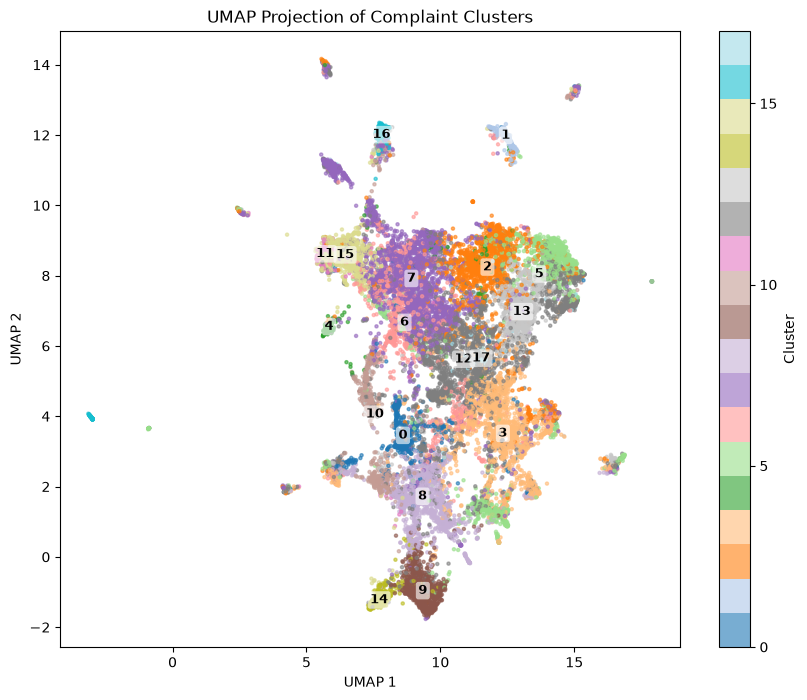

In [26]:
# Plot the UMAP
k = 18

cmap = plt.colormaps['tab20'].resampled(k)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_sample,
    cmap=cmap,
    s=5,
    alpha=0.6
)

# Annotate each cluster at its median UMAP position
cluster_arr = cluster_sample.values
for c in range(k):
    mask = cluster_arr == c
    if mask.sum() == 0:
        continue
    cx = np.median(X_umap[mask, 0])
    cy = np.median(X_umap[mask, 1])
    ax.text(
        cx, cy, str(c),
        fontsize=9, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
    )

ax.set_title('UMAP Projection of Complaint Clusters')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

cbar = plt.colorbar(scatter, ax=ax, ticks=range(0, k, 5))
cbar.set_label('Cluster')

plt.show()

In [27]:
chime_count = (
    df_narratives['Company']
    .str.contains('Chime', case=False, na=False)
    .sum()
)

print(f"Records where Company contains 'Chime': {chime_count:,}")

Records where Company contains 'Chime': 11,950


In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_svd)

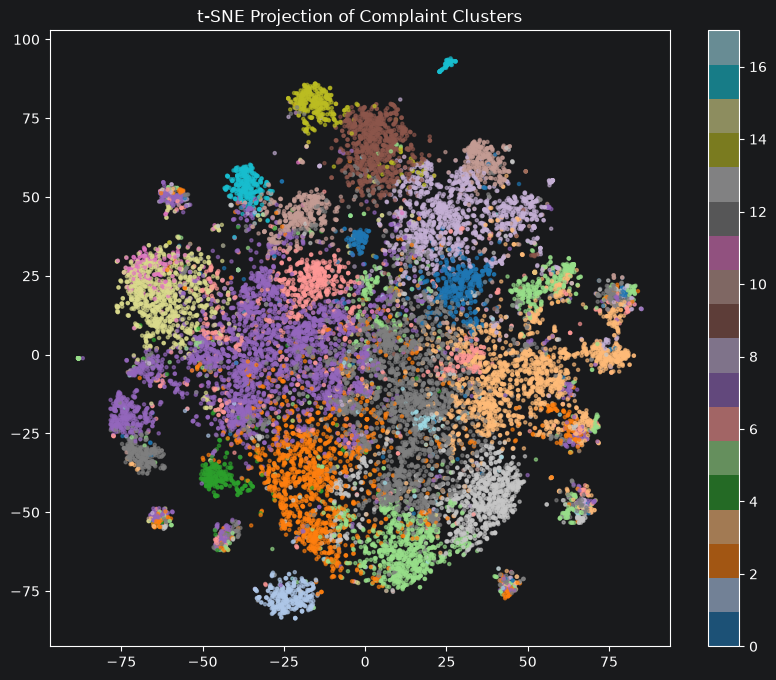

In [26]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_sample,
    cmap=plt.colormaps['tab20'].resampled(18),
    s=5,
    alpha=0.6
)

plt.colorbar(scatter)
plt.title('t-SNE Projection of Complaint Clusters')
plt.show()

In [94]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative,cluster,distance_to_centroid
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,...,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...,11,0.992864
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,...,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...,3,0.998468
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,...,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...,44,0.978543
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,...,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...,25,0.852135
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,...,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...,44,0.963603


In [95]:
df_narratives.info()

<class 'pandas.DataFrame'>
RangeIndex: 398004 entries, 0 to 398003
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 398004 non-null  datetime64[ms]
 1   Product                       398004 non-null  str           
 2   Sub-product                   398004 non-null  str           
 3   Issue                         398004 non-null  str           
 4   Sub-issue                     398004 non-null  str           
 5   Consumer complaint narrative  398004 non-null  str           
 6   Company public response       188952 non-null  str           
 7   Company                       398004 non-null  str           
 8   State                         398004 non-null  str           
 9   ZIP code                      398004 non-null  str           
 10  Tags                          83030 non-null   str           
 11  Consumer consent provide

In [102]:
df_narratives['cluster'].value_counts().sort_index(ascending=False)

cluster
59    14692
58     3797
57     3195
56     3186
55     8323
54        1
53     1611
52    14365
51      736
50     2580
49    11878
48        1
47     3795
46     4354
45    12061
44    23788
43     5717
42     6413
41     4910
40    13208
39     5635
38     6356
37     4491
36     5717
35    15604
34     6427
33        1
32    10975
31     2126
30        1
29        1
28     3134
27        1
26     6900
25    14668
24     1664
23     4408
22    11651
21     1695
20     5364
19     2209
18    11349
17        1
16     8986
15    10847
14        1
13     1379
12    10705
11    12998
10    10771
9      2682
8         2
7      2735
6     23631
5      2912
4      1166
3     45850
2         1
1       497
0      3852
Name: count, dtype: int64

In [96]:
OUTPUT_PATH = '../data/processed/clustered_narratives.parquet'

df_narratives.to_parquet(
    OUTPUT_PATH,
    index=False
)